In [ ]:
"""
Week 4 — Feature Selection & Feature Engineering
Phishing URL Detection Dataset
Tasks: correlation-based selection, RF importance, mutual information,
       RFE, domain-knowledge feature engineering
"""

import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif, RFE
from sklearn.preprocessing import RobustScaler
import warnings
warnings.filterwarnings('ignore')

# ══════════════════════════════════════════════════════════════════════════════
# PART A — FEATURE SELECTION ON PREPROCESSED DATASET
# ══════════════════════════════════════════════════════════════════════════════

# ── A1. Load Preprocessed Data ────────────────────────────────────────────────
print("=" * 65)
print("PART A — FEATURE SELECTION")
print("=" * 65)

df_pre = pd.read_csv("./Week3/full_preprocessed.csv")
X_pre  = df_pre.drop(columns=["status"])
y      = df_pre["status"]
print(f"\n  Preprocessed dataset loaded: {df_pre.shape}")
print(f"  Features: {X_pre.shape[1]}  |  Samples: {len(df_pre)}")

PART A — FEATURE SELECTION

  Preprocessed dataset loaded: (11430, 82)
  Features: 81  |  Samples: 11430


In [ ]:
# ── A2. Correlation-Based Selection ───────────────────────────────────────────
print("\n" + "-" * 65)
print("A2. CORRELATION WITH TARGET")
print("-" * 65)

corr_target = X_pre.corrwith(y).abs().sort_values(ascending=False)
print(f"\n  Top 20 features by |Pearson r| with target:\n")
print(f"  {'Rank':<6} {'Feature':<35} {'|r|':>8}")
print("  " + "-" * 52)
for rank, (feat, val) in enumerate(corr_target.head(20).items(), 1):
    print(f"  {rank:<6} {feat:<35} {val:>8.4f}")

low_corr = corr_target[corr_target < 0.05].index.tolist()
print(f"\n  Features with |r| < 0.05 (weak): {len(low_corr)}")
print(f"  {low_corr}")

# ── A3. Random Forest Feature Importance ──────────────────────────────────────
print("\n" + "-" * 65)
print("A3. RANDOM FOREST FEATURE IMPORTANCE")
print("-" * 65)

rf = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)
rf.fit(X_pre, y)
rf_imp = pd.Series(rf.feature_importances_, index=X_pre.columns).sort_values(ascending=False)

print(f"\n  Top 20 features by RF importance:\n")
print(f"  {'Rank':<6} {'Feature':<35} {'Importance':>12}")
print("  " + "-" * 56)
for rank, (feat, val) in enumerate(rf_imp.head(20).items(), 1):
    print(f"  {rank:<6} {feat:<35} {val:>12.5f}")

low_rf = rf_imp[rf_imp < 0.005].index.tolist()
print(f"\n  Features with RF importance < 0.005 (weak): {len(low_rf)}")


-----------------------------------------------------------------
A2. CORRELATION WITH TARGET
-----------------------------------------------------------------

  Top 20 features by |Pearson r| with target:

  Rank   Feature                                  |r|
  ----------------------------------------------------
  1      google_index                          0.7312
  2      page_rank                             0.5111
  3      nb_hyperlinks                         0.5087
  4      nb_www                                0.4435
  5      ratio_digits_url                      0.3623
  6      phish_hints                           0.3617
  7      web_traffic                           0.3614
  8      domain_in_title                       0.3428
  9      domain_age                            0.3319
  10     ip                                    0.3217
  11     longest_words_raw                     0.3140
  12     length_url                            0.3051
  13     nb_qm                    

In [ ]:
# ── A4. Mutual Information ────────────────────────────────────────────────────
print("\n" + "-" * 65)
print("A4. MUTUAL INFORMATION SCORES")
print("-" * 65)

mi_scores = mutual_info_classif(X_pre, y, random_state=42)
mi_series = pd.Series(mi_scores, index=X_pre.columns).sort_values(ascending=False)

print(f"\n  Top 20 features by Mutual Information:\n")
print(f"  {'Rank':<6} {'Feature':<35} {'MI Score':>10}")
print("  " + "-" * 54)
for rank, (feat, val) in enumerate(mi_series.head(20).items(), 1):
    print(f"  {rank:<6} {feat:<35} {val:>10.5f}")

low_mi = mi_series[mi_series < 0.01].index.tolist()
print(f"\n  Features with MI < 0.01 (weak): {len(low_mi)}")

# ── A5. RFE with Logistic Regression ─────────────────────────────────────────
print("\n" + "-" * 65)
print("A5. RECURSIVE FEATURE ELIMINATION (RFE) — TOP 30")
print("-" * 65)

lr = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
rfe = RFE(estimator=lr, n_features_to_select=30, step=5)
rfe.fit(X_pre, y)
rfe_selected = X_pre.columns[rfe.support_].tolist()
print(f"\n  RFE selected 30 features:")
for i, f in enumerate(rfe_selected, 1):
    print(f"    {i:>2}. {f}")


-----------------------------------------------------------------
A4. MUTUAL INFORMATION SCORES
-----------------------------------------------------------------

  Top 20 features by Mutual Information:

  Rank   Feature                               MI Score
  ------------------------------------------------------
  1      web_traffic                            0.30038
  2      google_index                           0.29903
  3      domain_age                             0.27871
  4      ratio_intHyperlinks                    0.24071
  5      ratio_extHyperlinks                    0.23846
  6      nb_hyperlinks                          0.23398
  7      page_rank                              0.22023
  8      safe_anchor                            0.18247
  9      domain_registration_length             0.14605
  10     ratio_extRedirection                   0.12463
  11     links_in_tags                          0.12210
  12     nb_www                                 0.11405
  13     

In [ ]:
# ── A6. Consensus Feature Selection ──────────────────────────────────────────
print("\n" + "-" * 65)
print("A6. CONSENSUS SELECTION (2-of-3 METHODS AGREE)")
print("-" * 65)

top_corr = set(corr_target.head(30).index)
top_rf   = set(rf_imp.head(30).index)
top_mi   = set(mi_series.head(30).index)
top_rfe  = set(rfe_selected)

consensus = []
for feat in X_pre.columns:
    votes = sum([feat in top_corr, feat in top_rf, feat in top_mi, feat in top_rfe])
    if votes >= 3:
        consensus.append(feat)

consensus_sorted = sorted(consensus, key=lambda f: rf_imp[f], reverse=True)
print(f"\n  Features selected by ≥3 methods: {len(consensus_sorted)}")
print(f"\n  {'Feature':<35} {'Corr':>8} {'RF_Imp':>10} {'MI':>10} {'RFE':>6}")
print("  " + "-" * 72)
for feat in consensus_sorted:
    in_rfe = "✓" if feat in top_rfe else "✗"
    print(f"  {feat:<35} {corr_target[feat]:>8.4f} {rf_imp[feat]:>10.5f} "
          f"{mi_series[feat]:>10.5f} {in_rfe:>6}")

# ── A7. Features to Drop ──────────────────────────────────────────────────────
drop_features = list(set(low_corr) & set(low_rf) & set(low_mi))
print(f"\n  Features weak in ALL three methods (candidates to drop): {len(drop_features)}")
print(f"  {drop_features}")


-----------------------------------------------------------------
A6. CONSENSUS SELECTION (2-of-3 METHODS AGREE)
-----------------------------------------------------------------

  Features selected by ≥3 methods: 22

  Feature                                 Corr     RF_Imp         MI    RFE
  ------------------------------------------------------------------------
  google_index                          0.7312    0.18576    0.29903      ✓
  page_rank                             0.5111    0.11771    0.22023      ✓
  web_traffic                           0.3614    0.08181    0.30038      ✓
  nb_hyperlinks                         0.5087    0.08099    0.23398      ✓
  nb_www                                0.4435    0.03951    0.11405      ✓
  ratio_extHyperlinks                   0.0490    0.03723    0.23846      ✓
  domain_age                            0.3319    0.03073    0.27871      ✓
  longest_word_path                     0.2873    0.02771    0.10905      ✗
  phish_hints        

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# PART B — FEATURE ENGINEERING FROM RAW DATA
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("PART B — FEATURE ENGINEERING (DOMAIN KNOWLEDGE)")
print("=" * 65)


# ── B1. Load Raw Data ─────────────────────────────────────────────────────────
df_raw = pd.read_csv("./data/dataset_phishing.csv")
df_raw['domain_age'] = df_raw['domain_age'].clip(lower=0)
df_raw['domain_registration_length'] = df_raw['domain_registration_length'].clip(lower=0)
df_raw.drop_duplicates(inplace=True)

# Remove zero-variance columns
zero_var = ['nb_or','ratio_nullHyperlinks','ratio_intRedirection',
            'ratio_intErrors','submit_email','sfh']
df_raw.drop(columns=zero_var, inplace=True)

# Encode target
df_raw['status'] = (df_raw['status'] == 'phishing').astype(int)

print(f"\n  Raw dataset loaded: {df_raw.shape}")
print(f"  Engineering new features...")


PART B — FEATURE ENGINEERING (DOMAIN KNOWLEDGE)

  Raw dataset loaded: (11430, 83)
  Engineering new features...


In [ ]:
# ── B2. URL Structural Features ───────────────────────────────────────────────
print("\n  [B2] URL Structural Features")

# Total number of special characters in URL
df_raw['url_complexity'] = (
    df_raw['nb_dots'] + df_raw['nb_hyphens'] + df_raw['nb_at'] +
    df_raw['nb_slash'] + df_raw['nb_qm'] + df_raw['nb_eq']
)
print("    + url_complexity: sum of dots, hyphens, @, /, ?, =")

# Ratio of suspicious special chars to URL length
df_raw['special_char_ratio'] = (
    df_raw['nb_at'] + df_raw['nb_percent'] + df_raw['nb_dollar'] +
    df_raw['nb_semicolumn'] + df_raw['nb_comma'] + df_raw['nb_star'] +
    df_raw['nb_tilde'] + df_raw['nb_colon']
) / (df_raw['length_url'] + 1)
print("    + special_char_ratio: rare chars / url_length")

# URL length category (binned)
df_raw['url_len_cat'] = pd.cut(
    df_raw['length_url'],
    bins=[0, 30, 75, 150, np.inf],
    labels=[0, 1, 2, 3]
).astype(int)
print("    + url_len_cat: 0=short(<30), 1=medium(<75), 2=long(<150), 3=very_long")

# Path depth (proxy: number of slashes beyond base)
df_raw['path_depth'] = (df_raw['nb_slash'] - 2).clip(lower=0)
print("    + path_depth: nb_slash - 2 (depth beyond domain root)")

# Hostname to URL length ratio
df_raw['hostname_url_ratio'] = df_raw['length_hostname'] / (df_raw['length_url'] + 1)
print("    + hostname_url_ratio: length_hostname / length_url")


  [B2] URL Structural Features
    + url_complexity: sum of dots, hyphens, @, /, ?, =
    + special_char_ratio: rare chars / url_length
    + url_len_cat: 0=short(<30), 1=medium(<75), 2=long(<150), 3=very_long
    + path_depth: nb_slash - 2 (depth beyond domain root)
    + hostname_url_ratio: length_hostname / length_url


In [ ]:
# ── B3. Subdomain & Domain Features ──────────────────────────────────────────
print("\n  [B3] Subdomain & Domain Features")

# Deep subdomain flag
df_raw['deep_subdomain'] = (df_raw['nb_subdomains'] >= 3).astype(int)
print("    + deep_subdomain: 1 if subdomains >= 3")

# Domain obfuscation: uses IP + has hyphens + uses prefix/suffix
df_raw['domain_obfuscation'] = (
    df_raw['ip'] + df_raw['prefix_suffix'] + df_raw['random_domain'] +
    df_raw['abnormal_subdomain']
).clip(upper=1)
print("    + domain_obfuscation: composite flag (ip|prefix_suffix|random|abnormal)")

# Brand impersonation via subdomain
df_raw['brand_impersonation'] = (
    (df_raw['domain_in_brand'] == 0) & (df_raw['brand_in_subdomain'] == 1)
).astype(int)
print("    + brand_impersonation: brand in subdomain but not in domain itself")


  [B3] Subdomain & Domain Features
    + deep_subdomain: 1 if subdomains >= 3
    + domain_obfuscation: composite flag (ip|prefix_suffix|random|abnormal)
    + brand_impersonation: brand in subdomain but not in domain itself


In [ ]:
# ── B4. Content & Hyperlink Features ─────────────────────────────────────────
print("\n  [B4] Content & Hyperlink Features")

# External link dominance
df_raw['ext_link_dominant'] = (
    df_raw['ratio_extHyperlinks'] > df_raw['ratio_intHyperlinks']
).astype(int)
print("    + ext_link_dominant: 1 if external links outnumber internal")

# Hyperlink diversity
df_raw['hyperlink_diversity'] = (
    df_raw['ratio_extHyperlinks'] - df_raw['ratio_intHyperlinks']
).abs()
print("    + hyperlink_diversity: |ext_ratio - int_ratio|")

# Redirection intensity
df_raw['redirection_intensity'] = (
    df_raw['nb_redirection'] + df_raw['nb_external_redirection'] * 2
)
print("    + redirection_intensity: nb_redirection + 2*nb_external_redirection")


  [B4] Content & Hyperlink Features
    + ext_link_dominant: 1 if external links outnumber internal
    + hyperlink_diversity: |ext_ratio - int_ratio|
    + redirection_intensity: nb_redirection + 2*nb_external_redirection


In [ ]:
# ── B5. Word / Token Features ─────────────────────────────────────────────────
print("\n  [B5] Word & Token Features")

# Word length range
df_raw['word_length_range'] = df_raw['longest_words_raw'] - df_raw['shortest_words_raw']
print("    + word_length_range: longest - shortest token length")

# Digit-heavy URL flag
df_raw['digit_heavy'] = (df_raw['ratio_digits_url'] > 0.1).astype(int)
print("    + digit_heavy: 1 if >10% of URL chars are digits")

# Short average word (obfuscated paths tend to have short random tokens)
df_raw['short_avg_word'] = (df_raw['avg_words_raw'] < 5).astype(int)
print("    + short_avg_word: 1 if avg token length < 5 chars")


  [B5] Word & Token Features
    + word_length_range: longest - shortest token length
    + digit_heavy: 1 if >10% of URL chars are digits
    + short_avg_word: 1 if avg token length < 5 chars


In [ ]:
# ── B6. Trust & Reputation Features ──────────────────────────────────────────
print("\n  [B6] Trust & Reputation Features")

# Composite domain trust score
df_raw['domain_trust_score'] = (
    df_raw['google_index'] +
    df_raw['dns_record'] +
    df_raw['whois_registered_domain'] +
    (df_raw['domain_age'] > 365).astype(int) +
    (df_raw['page_rank'] > 3).astype(int)
)
print("    + domain_trust_score: google_index + dns_record + whois + age>1yr + rank>3")

# New/unregistered domain flag
df_raw['new_domain'] = (
    (df_raw['domain_age'] < 180) & (df_raw['domain_registration_length'] < 365)
).astype(int)
print("    + new_domain: 1 if domain_age < 180 days AND reg_length < 365 days")

# High page rank flag
df_raw['high_page_rank'] = (df_raw['page_rank'] >= 5).astype(int)
print("    + high_page_rank: 1 if page_rank >= 5")


  [B6] Trust & Reputation Features
    + domain_trust_score: google_index + dns_record + whois + age>1yr + rank>3
    + new_domain: 1 if domain_age < 180 days AND reg_length < 365 days
    + high_page_rank: 1 if page_rank >= 5


In [ ]:
# ── B7. Suspicious Behaviour Flag ─────────────────────────────────────────────
print("\n  [B7] Composite Suspicious Behaviour")

df_raw['suspicious_structure'] = (
    (df_raw['ip'] == 1) |
    (df_raw['https_token'] == 0) |
    (df_raw['prefix_suffix'] == 1) |
    (df_raw['shortening_service'] == 1)
).astype(int)
print("    + suspicious_structure: uses IP / no HTTPS / prefix-suffix / shortener")


  [B7] Composite Suspicious Behaviour
    + suspicious_structure: uses IP / no HTTPS / prefix-suffix / shortener


In [ ]:
# ── B8. Summary of Engineered Features ───────────────────────────────────────
new_features = [
    'url_complexity', 'special_char_ratio', 'url_len_cat', 'path_depth',
    'hostname_url_ratio', 'deep_subdomain', 'domain_obfuscation',
    'brand_impersonation', 'ext_link_dominant', 'hyperlink_diversity',
    'redirection_intensity', 'word_length_range', 'digit_heavy',
    'short_avg_word', 'domain_trust_score', 'new_domain', 'high_page_rank',
    'suspicious_structure'
]

print(f"\n  Total new features engineered: {len(new_features)}")
print(f"\n  Correlation of new features with target:")
print(f"\n  {'Feature':<30} {'|r|':>8}  Direction")
print("  " + "-" * 55)
for feat in new_features:
    c = df_raw[feat].corr(df_raw['status'])
    direction = "↑ phishing" if c > 0 else "↑ legit"
    print(f"  {feat:<30} {abs(c):>8.4f}  {direction}")


  Total new features engineered: 18

  Correlation of new features with target:

  Feature                             |r|  Direction
  -------------------------------------------------------
  url_complexity                   0.2113  ↑ phishing
  special_char_ratio               0.1774  ↑ legit
  url_len_cat                      0.3103  ↑ phishing
  path_depth                       0.2423  ↑ phishing
  hostname_url_ratio               0.1150  ↑ legit
  deep_subdomain                   0.2053  ↑ phishing
  domain_obfuscation               0.3198  ↑ phishing
  brand_impersonation              0.0643  ↑ phishing
  ext_link_dominant                0.1553  ↑ phishing
  hyperlink_diversity              0.0294  ↑ phishing
  redirection_intensity            0.0150  ↑ legit
  word_length_range                0.2020  ↑ phishing
  digit_heavy                      0.3131  ↑ phishing
  short_avg_word                   0.0766  ↑ legit
  domain_trust_score               0.1469  ↑ phishing
  new_dom

In [ ]:
# ── B9. Build Refined Dataset ─────────────────────────────────────────────────
print("\n" + "=" * 65)
print("PART C — BUILDING REFINED DATASET")
print("=" * 65)

# Drop URL and zero-variance (already removed), apply same Week 3 preprocessing
df_refined = df_raw.drop(columns=['url'], errors='ignore')

# Identify binary vs continuous (pre-scaling)
TARGET = 'status'
all_feats = [c for c in df_refined.columns if c != TARGET]
binary_cols = [c for c in all_feats if set(df_refined[c].dropna().unique()).issubset({0,1})]
cont_cols   = [c for c in all_feats if c not in binary_cols]

# Log1p on high-skew continuous
skew = df_refined[cont_cols].skew()
high_skew = skew[skew.abs() > 1].index.tolist()
df_refined[high_skew] = np.log1p(df_refined[high_skew])

# RobustScaler on continuous
scaler = RobustScaler()
df_refined[cont_cols] = scaler.fit_transform(df_refined[cont_cols])

print(f"\n  Refined dataset shape: {df_refined.shape}")
print(f"  Original features   : {X_pre.shape[1]}")
print(f"  New features added  : {len(new_features)}")
print(f"  Total features      : {df_refined.shape[1] - 1}")

# Train/Test split
from sklearn.model_selection import train_test_split
X_ref = df_refined.drop(columns=[TARGET])
y_ref = df_refined[TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X_ref, y_ref, test_size=0.2, random_state=42, stratify=y_ref
)
train_ref = pd.concat([X_train, y_train], axis=1)
test_ref  = pd.concat([X_test,  y_test],  axis=1)
train_ref.to_csv("./Week4/train_refined.csv", index=False)
test_ref.to_csv("./Week4/test_refined.csv",   index=False)
df_refined.to_csv("./Week4/full_refined.csv", index=False)
print(f"\n  Saved: train_refined.csv  ({train_ref.shape})")
print(f"  Saved: test_refined.csv   ({test_ref.shape})")
print(f"  Saved: full_refined.csv   ({df_refined.shape})")

# Also save feature importance summary
feat_summary = pd.DataFrame({
    'correlation': corr_target,
    'rf_importance': rf_imp,
    'mutual_info': mi_series,
    'rfe_selected': pd.Series({f: 1 for f in rfe_selected}, dtype=int)
}).fillna(0).sort_values('rf_importance', ascending=False)
feat_summary.to_csv("./Week4/feature_importance_summary.csv")
print("  Saved: feature_importance_summary.csv")


PART C — BUILDING REFINED DATASET

  Refined dataset shape: (11430, 100)
  Original features   : 81
  New features added  : 18
  Total features      : 99

  Saved: train_refined.csv  ((9144, 100))
  Saved: test_refined.csv   ((2286, 100))
  Saved: full_refined.csv   ((11430, 100))
  Saved: feature_importance_summary.csv



GENERATING VISUALIZATIONS
  Saved: fig_w4_rf_importance.png


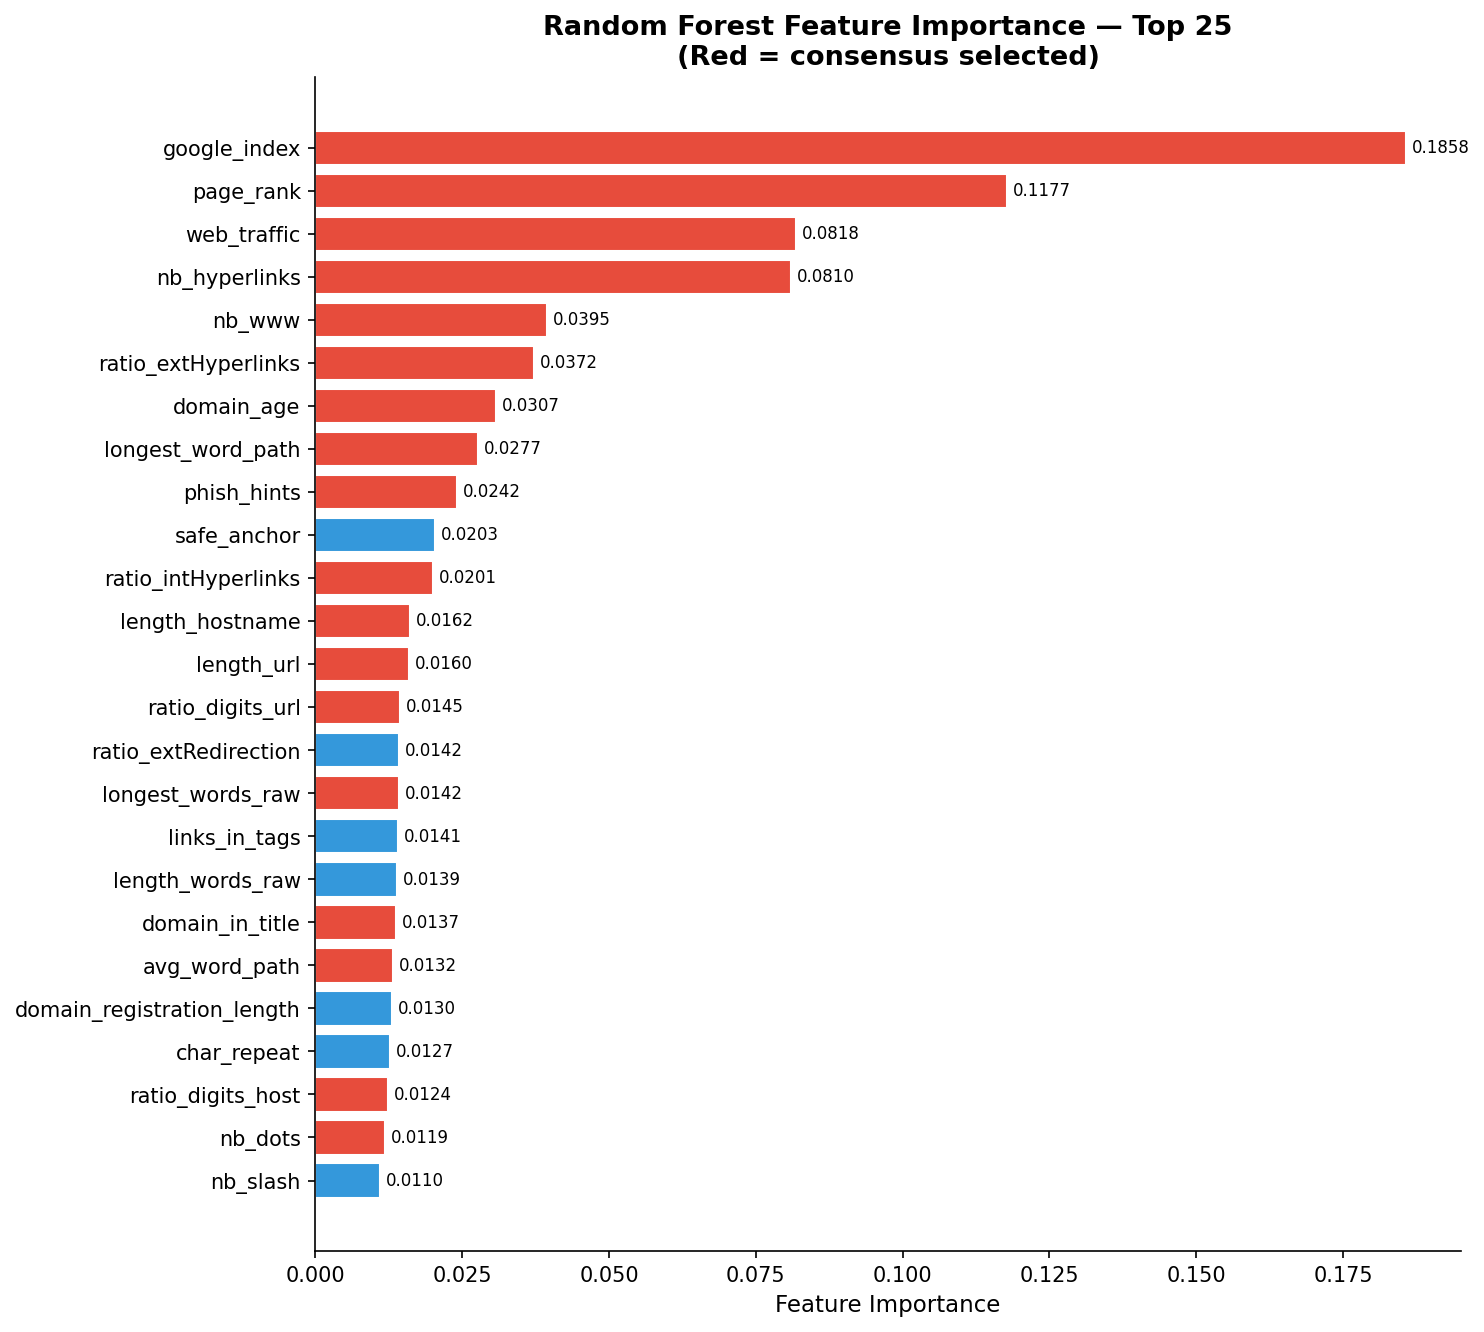

In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# VISUALIZATIONS
# ══════════════════════════════════════════════════════════════════════════════
import os
from IPython.display import Image, display

print("\n" + "=" * 65)
print("GENERATING VISUALIZATIONS")
print("=" * 65)

# ── Fig 1: RF Feature Importance — Top 25 ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 9))
top25 = rf_imp.head(25)
colors = ['#e74c3c' if f in consensus_sorted else '#3498db' for f in top25.index]
bars = ax.barh(top25.index[::-1], top25.values[::-1], color=colors[::-1], edgecolor='white')
ax.set_xlabel("Feature Importance", fontsize=11)
ax.set_title("Random Forest Feature Importance — Top 25\n(Red = consensus selected)", fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for bar, val in zip(bars, top25.values[::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('./Week4/fig_w4_rf_importance.png', dpi=150, bbox_inches='tight')
plt.close()
print("  Saved: fig_w4_rf_importance.png")
display(Image(filename='./Week4/fig_w4_rf_importance.png'))

  Saved: fig_w4_mutual_info.png


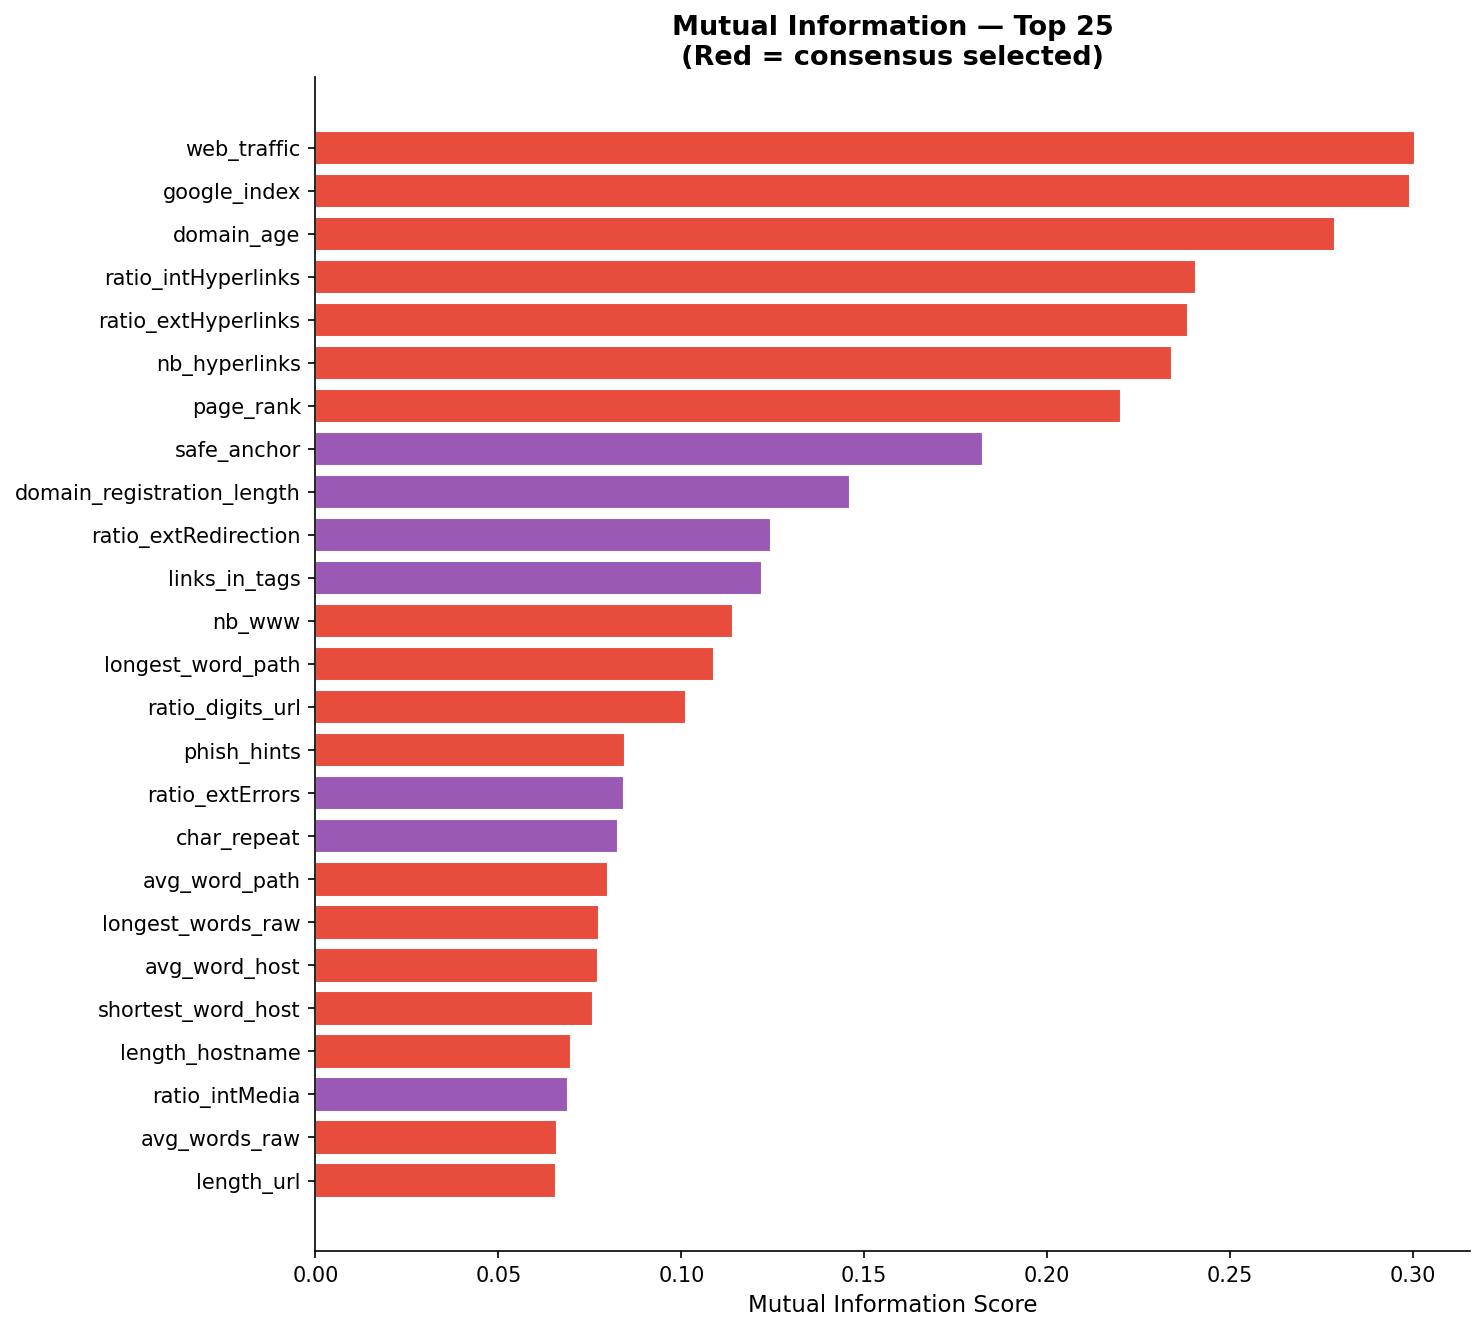

In [18]:
# ── Fig 2: Mutual Information — Top 25 ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 9))
top25_mi = mi_series.head(25)
colors_mi = ['#e74c3c' if f in consensus_sorted else '#9b59b6' for f in top25_mi.index]
ax.barh(top25_mi.index[::-1], top25_mi.values[::-1], color=colors_mi[::-1], edgecolor='white')
ax.set_xlabel("Mutual Information Score", fontsize=11)
ax.set_title("Mutual Information — Top 25\n(Red = consensus selected)", fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('./Week4/fig_w4_mutual_info.png', dpi=150, bbox_inches='tight')
plt.close()
print("  Saved: fig_w4_mutual_info.png")
display(Image(filename='./Week4/fig_w4_mutual_info.png'))

  Saved: fig_w4_method_comparison.png


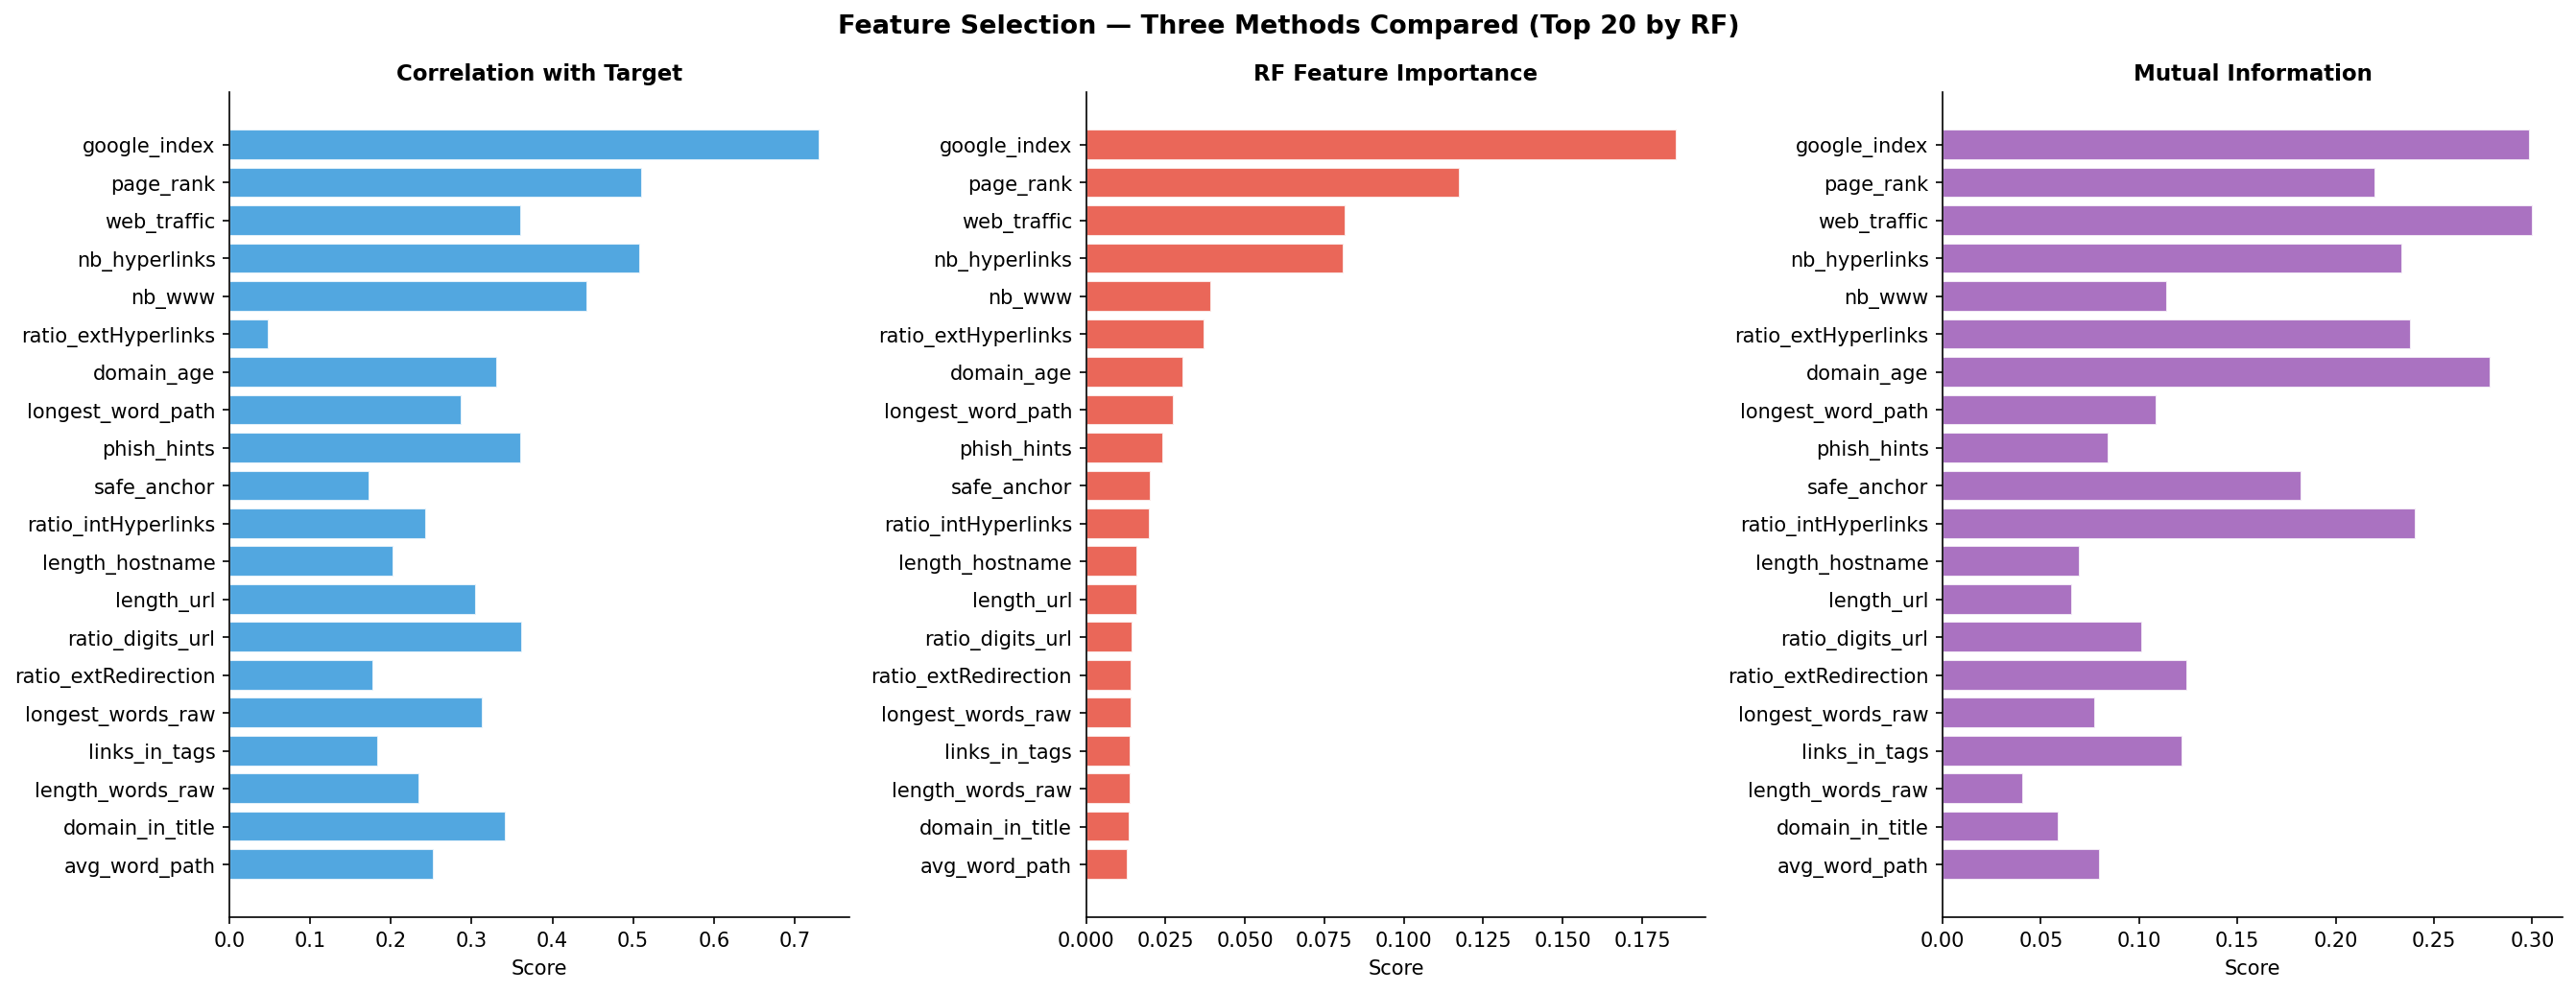

In [19]:
# ── Fig 3: Method Comparison (Top 20 by RF) ───────────────────────────────────
top20_feats = rf_imp.head(20).index.tolist()
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
metrics = [
    (corr_target[top20_feats], '#3498db', 'Correlation with Target'),
    (rf_imp[top20_feats],      '#e74c3c', 'RF Feature Importance'),
    (mi_series[top20_feats],   '#9b59b6', 'Mutual Information'),
]
for ax, (vals, color, title) in zip(axes, metrics):
    ax.barh(top20_feats[::-1], vals.values[::-1], color=color, alpha=0.85, edgecolor='white')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Score')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
fig.suptitle("Feature Selection — Three Methods Compared (Top 20 by RF)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('./Week4/fig_w4_method_comparison.png', dpi=150, bbox_inches='tight')
plt.close()
print("  Saved: fig_w4_method_comparison.png")
display(Image(filename='./Week4/fig_w4_method_comparison.png'))

  Saved: fig_w4_new_features_corr.png


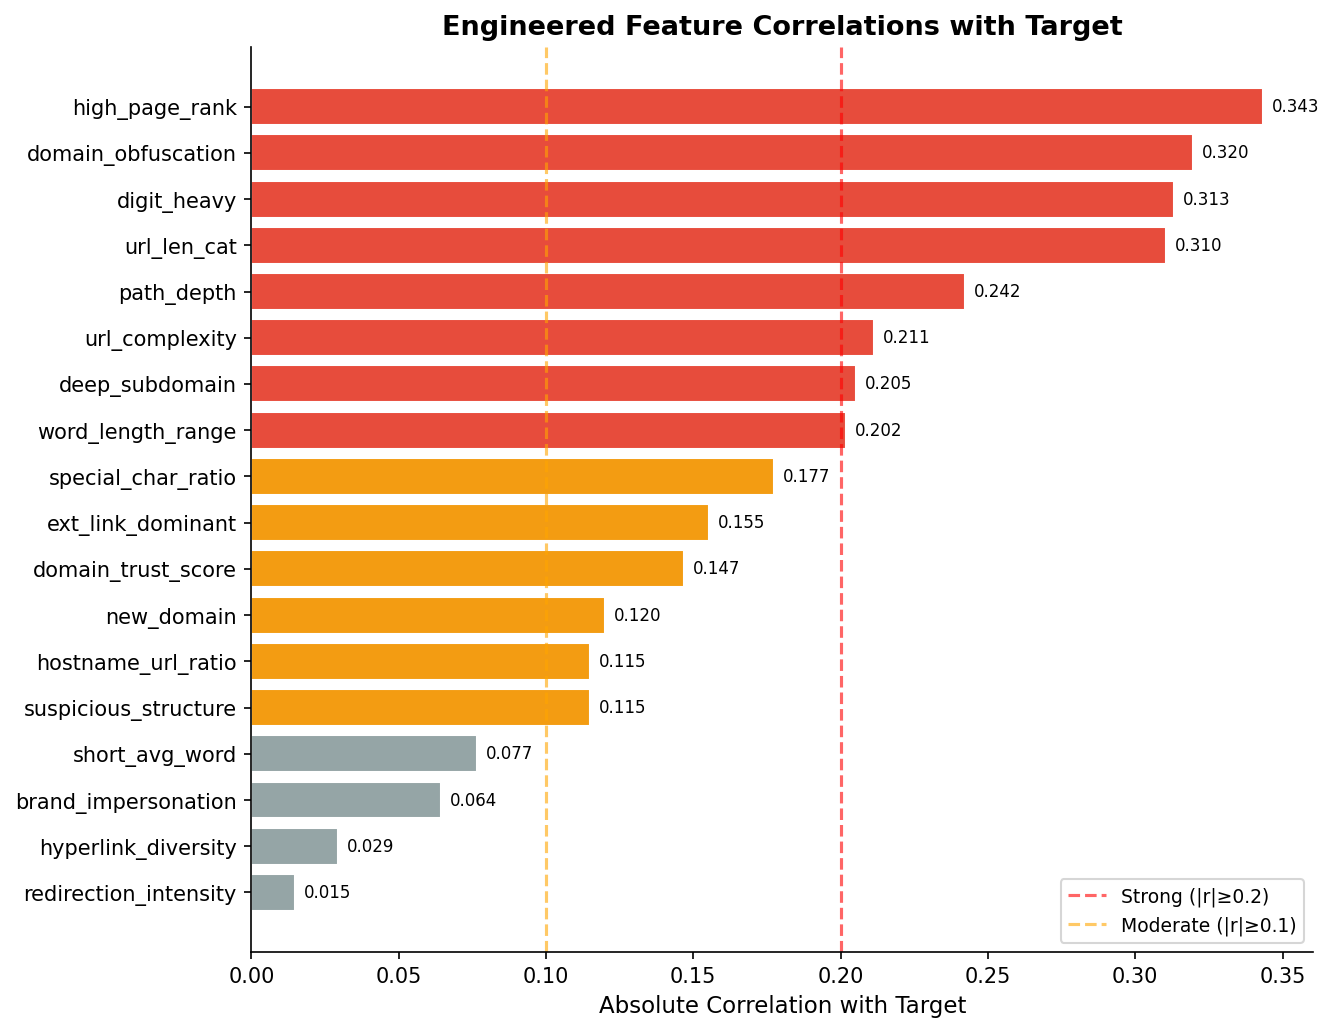

In [20]:
# ── Fig 4: New Features Correlation ───────────────────────────────────────────
new_corrs = {f: abs(df_raw[f].corr(df_raw['status'])) for f in new_features}
new_corrs_s = pd.Series(new_corrs).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(9, 7))
colors_new = ['#e74c3c' if v >= 0.2 else '#f39c12' if v >= 0.1 else '#95a5a6'
              for v in new_corrs_s.values]
ax.barh(new_corrs_s.index, new_corrs_s.values, color=colors_new, edgecolor='white')
ax.axvline(0.2, color='red', linestyle='--', alpha=0.6, label='Strong (|r|≥0.2)')
ax.axvline(0.1, color='orange', linestyle='--', alpha=0.6, label='Moderate (|r|≥0.1)')
ax.set_xlabel("Absolute Correlation with Target", fontsize=11)
ax.set_title("Engineered Feature Correlations with Target", fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for i, (feat, val) in enumerate(new_corrs_s.items()):
    ax.text(val + 0.003, i, f'{val:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('./Week4/fig_w4_new_features_corr.png', dpi=150, bbox_inches='tight')
plt.close()
print("  Saved: fig_w4_new_features_corr.png")
display(Image(filename='./Week4/fig_w4_new_features_corr.png'))

  Saved: fig_w4_new_feat_dist.png


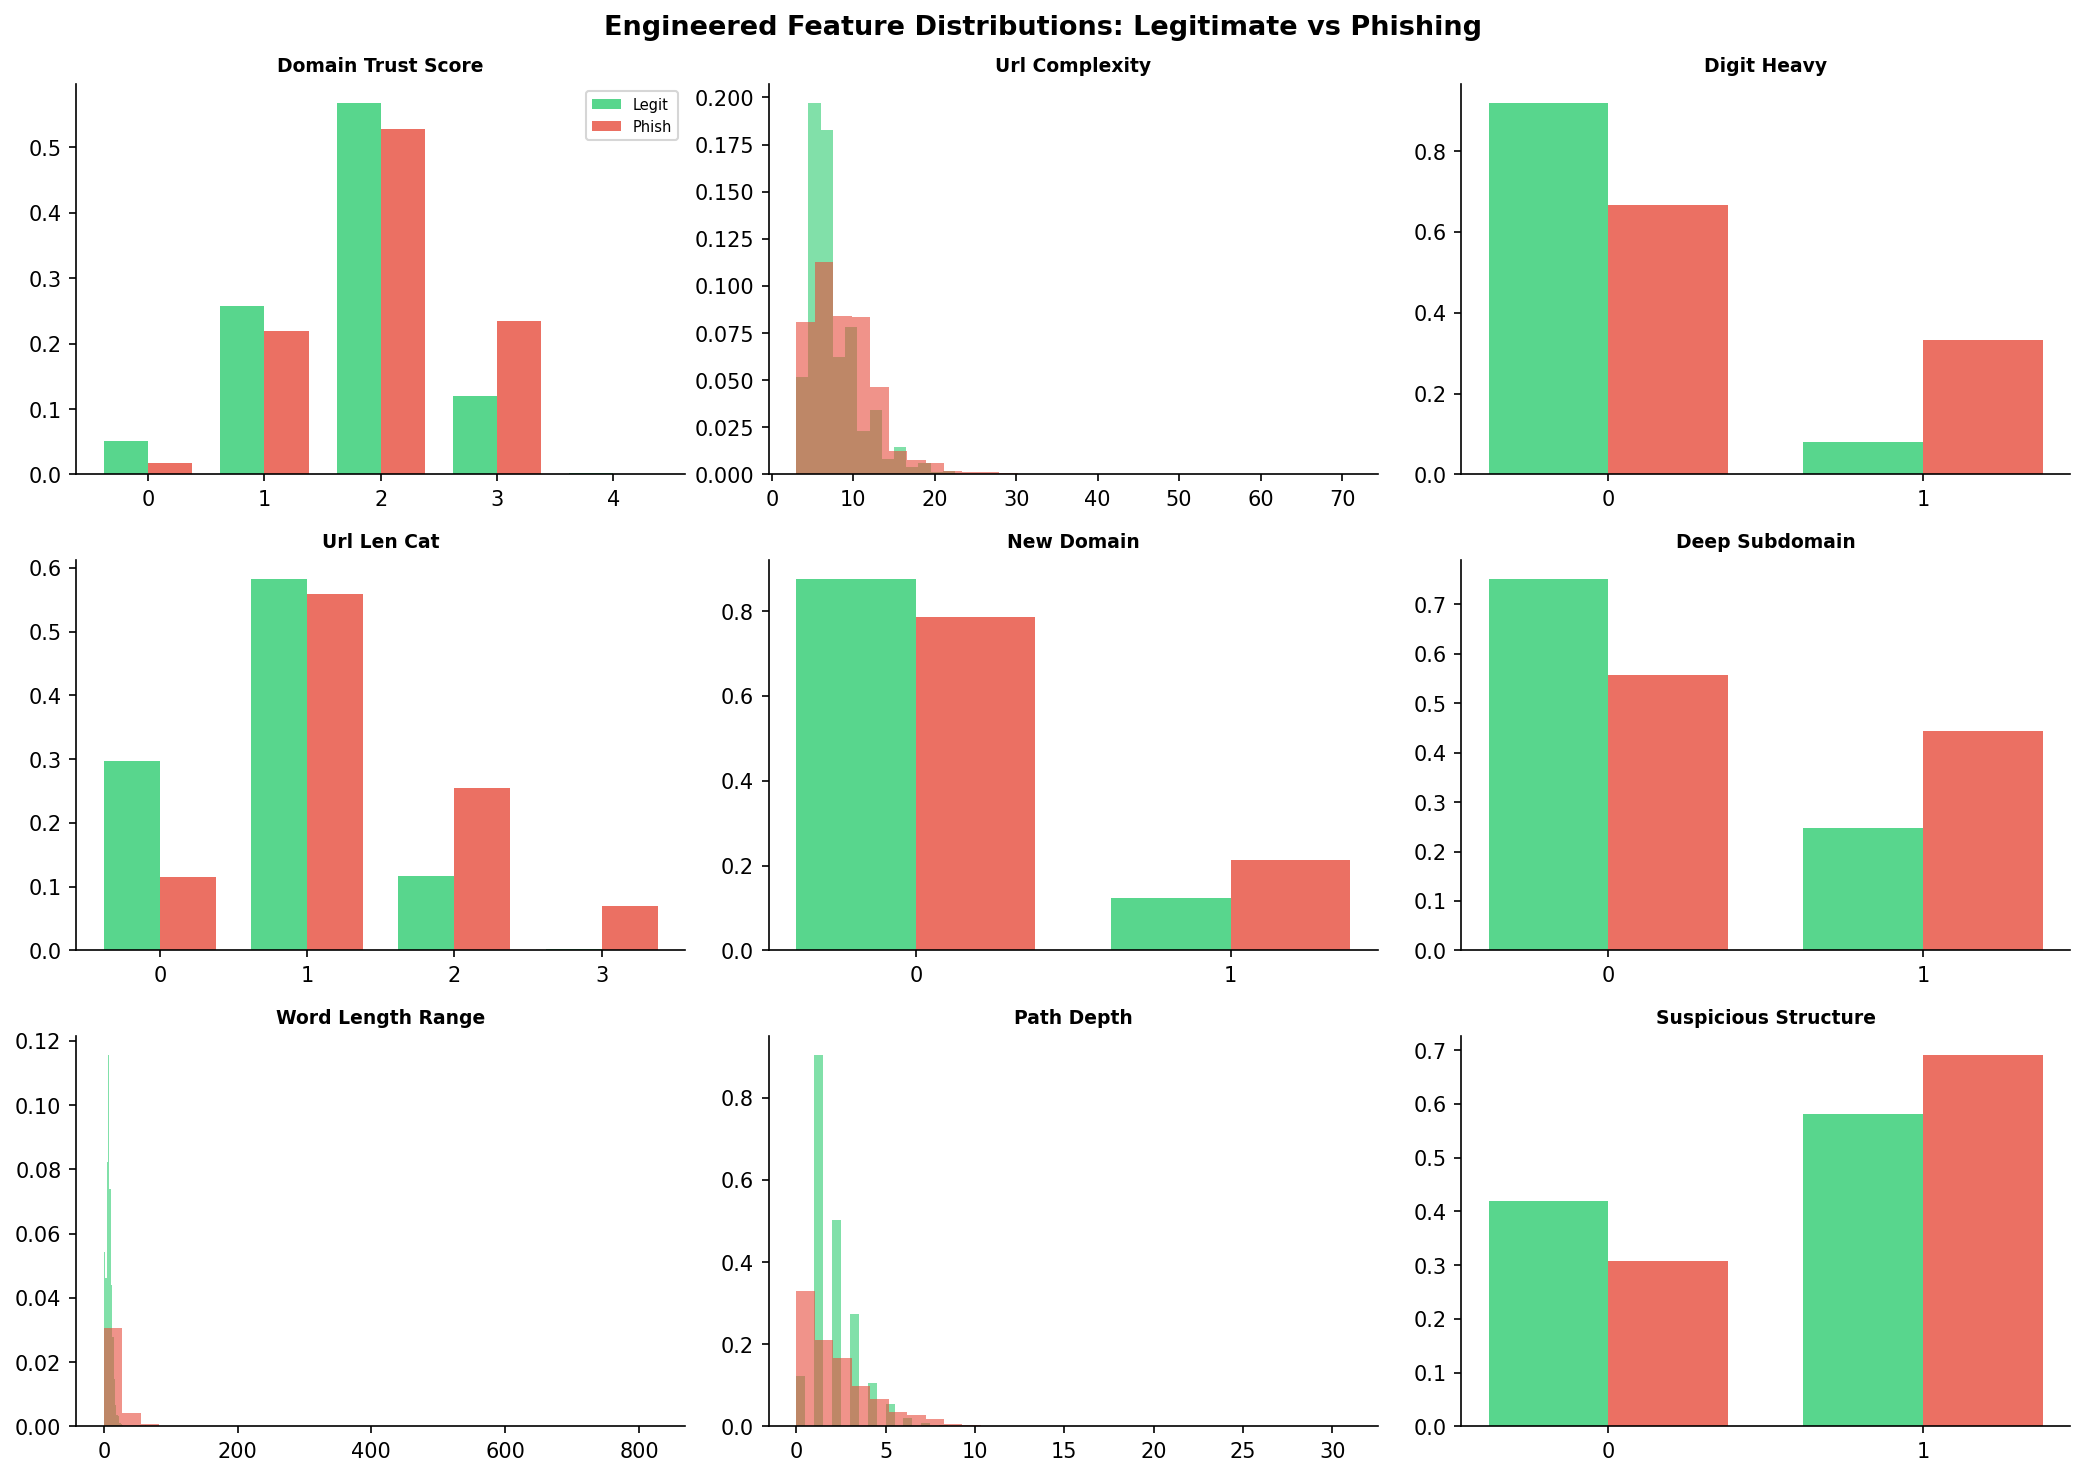

In [22]:
# ── Fig 5: New Feature Distributions by Class ─────────────────────────────────
top_new = ['domain_trust_score', 'url_complexity', 'digit_heavy',
           'url_len_cat', 'new_domain', 'deep_subdomain',
           'word_length_range', 'path_depth', 'suspicious_structure']
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()
for i, feat in enumerate(top_new):
    ax = axes[i]
    phish = df_raw[df_raw['status'] == 1][feat]
    legit = df_raw[df_raw['status'] == 0][feat]
    if df_raw[feat].nunique() <= 6:
        vals = sorted(df_raw[feat].unique())
        x = np.arange(len(vals))
        w = 0.38
        l_counts = [legit[legit == v].shape[0] / len(legit) for v in vals]
        p_counts = [phish[phish == v].shape[0] / len(phish) for v in vals]
        ax.bar(x - w/2, l_counts, w, label='Legit', color='#2ecc71', alpha=0.8)
        ax.bar(x + w/2, p_counts, w, label='Phish', color='#e74c3c', alpha=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels([str(v) for v in vals])
    else:
        ax.hist(legit, bins=30, alpha=0.6, color='#2ecc71', label='Legit', density=True)
        ax.hist(phish, bins=30, alpha=0.6, color='#e74c3c', label='Phish', density=True)
    ax.set_title(feat.replace('_', ' ').title(), fontsize=9, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if i == 0:
        ax.legend(fontsize=7)
fig.suptitle("Engineered Feature Distributions: Legitimate vs Phishing",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('./Week4/fig_w4_new_feat_dist.png', dpi=150, bbox_inches='tight')
plt.close()
print("  Saved: fig_w4_new_feat_dist.png")
display(Image(filename='./Week4/fig_w4_new_feat_dist.png'))

  Saved: fig_w4_method_agreement.png


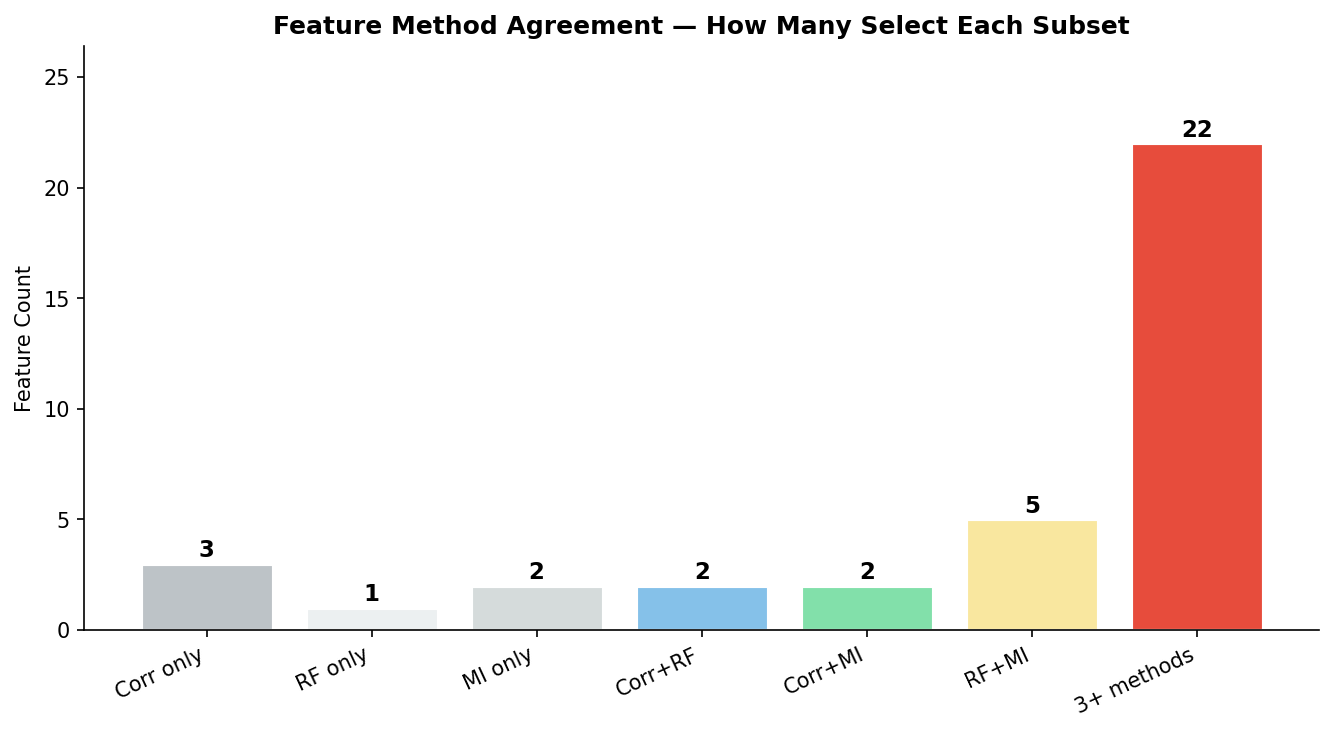


WEEK 4 COMPLETE
  Consensus features selected : 22
  New features engineered     : 18
  Final refined feature count : 99
  Train shape                 : (9144, 100)
  Test  shape                 : (2286, 100)


In [23]:
# ── Fig 6: Feature Selection Venn Summary ─────────────────────────────────────
method_counts = {
    'Corr only':    len(top_corr - top_rf - top_mi - top_rfe),
    'RF only':      len(top_rf - top_corr - top_mi - top_rfe),
    'MI only':      len(top_mi - top_corr - top_rf - top_rfe),
    'Corr+RF':      len((top_corr & top_rf) - top_mi - top_rfe),
    'Corr+MI':      len((top_corr & top_mi) - top_rf - top_rfe),
    'RF+MI':        len((top_rf & top_mi) - top_corr - top_rfe),
    '3+ methods':   len(set(consensus_sorted)),
}
fig, ax = plt.subplots(figsize=(9, 5))
labels = list(method_counts.keys())
values = list(method_counts.values())
colors_v = ['#bdc3c7','#ecf0f1','#d5dbdb','#85c1e9','#82e0aa','#f9e79f','#e74c3c']
bars = ax.bar(labels, values, color=colors_v, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(val), ha='center', fontsize=11, fontweight='bold')
ax.set_title("Feature Method Agreement — How Many Select Each Subset",
             fontsize=12, fontweight='bold')
ax.set_ylabel("Feature Count")
ax.set_ylim(0, max(values) * 1.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig('./Week4/fig_w4_method_agreement.png', dpi=150, bbox_inches='tight')
plt.close()
print("  Saved: fig_w4_method_agreement.png")
display(Image(filename='./Week4/fig_w4_method_agreement.png'))

print("\n" + "=" * 65)
print("WEEK 4 COMPLETE")
print("=" * 65)
print(f"  Consensus features selected : {len(consensus_sorted)}")
print(f"  New features engineered     : {len(new_features)}")
print(f"  Final refined feature count : {df_refined.shape[1] - 1}")
print(f"  Train shape                 : {train_ref.shape}")
print(f"  Test  shape                 : {test_ref.shape}")